In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [37]:
os.makedirs("corrected", exist_ok=True)
os.makedirs("enhanced", exist_ok=True)

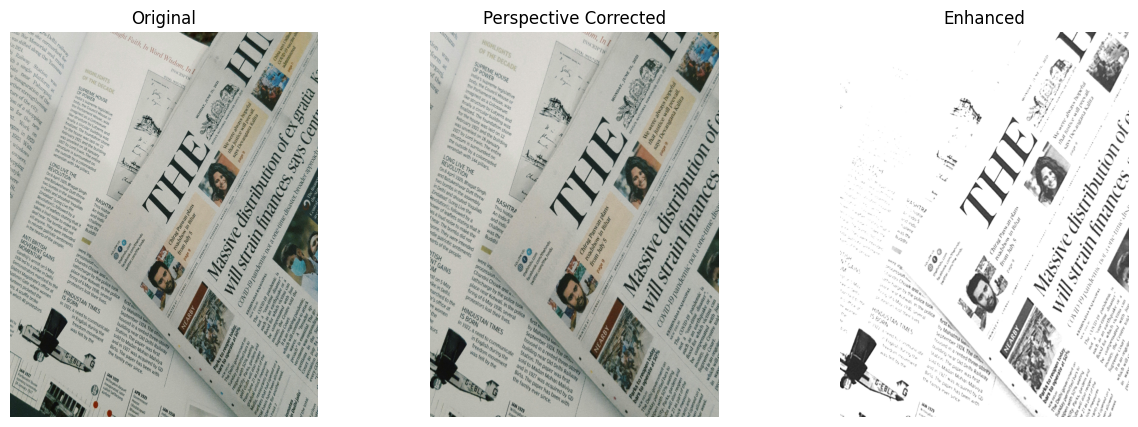

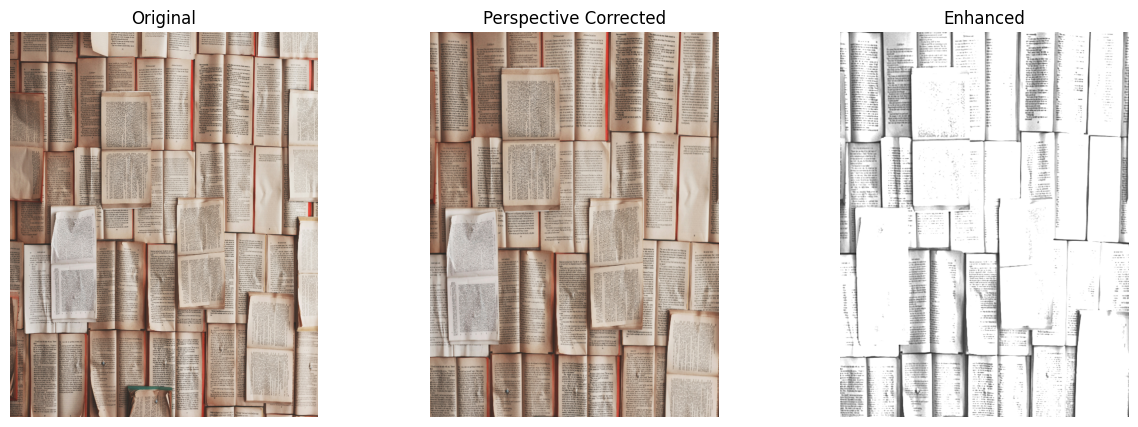

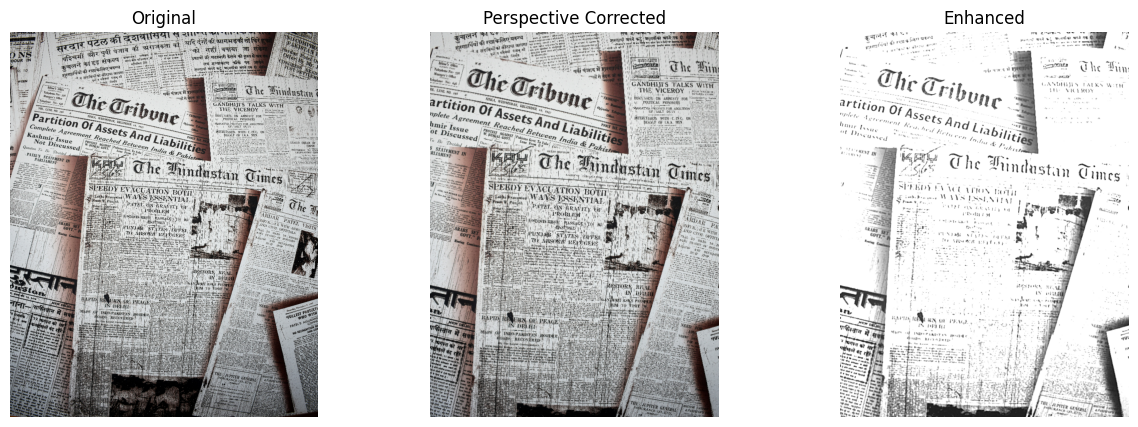

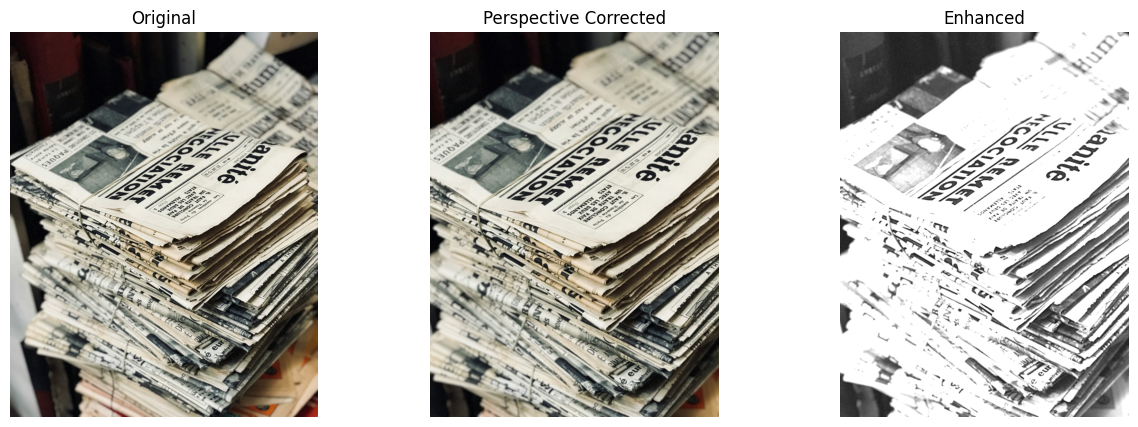

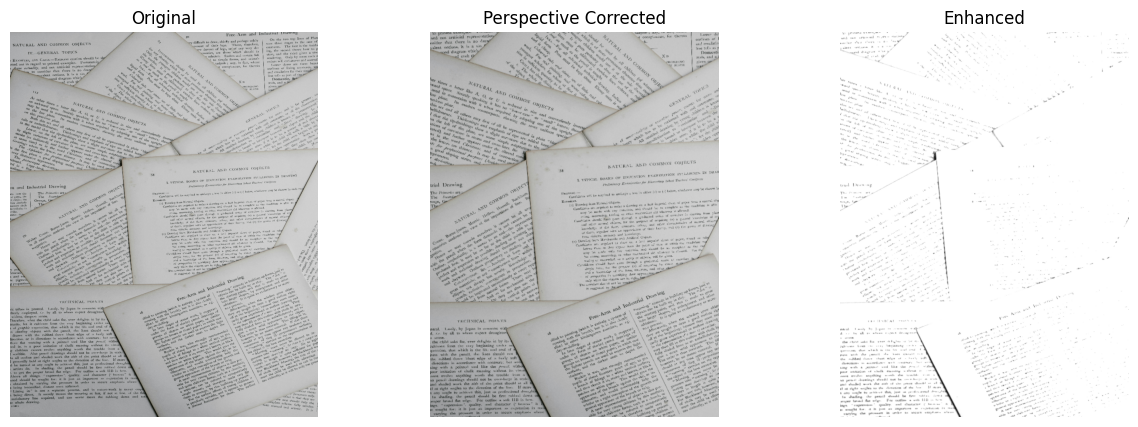

In [38]:
files = [
    "doc1.jpg",
    "doc2.jpg",
    "doc3.jpg",
    "doc4.jpg",
    "doc5.jpg"
]

for file in files:
    path = os.path.join("documents", file)
    image = cv2.imread(path)

    if image is None:
        print(f"Cannot read {file}")
        continue

    h, w = image.shape[:2]
    # Resize image
    image = cv2.resize(image, (800, 1000))

    # Perspective Correction

    pts1 = np.float32([
        [80, 80],      # Top Left
        [720, 80],     # Top Right
        [60, 920],     # Bottom Left
        [740, 920]     # Bottom Right
    ])

    pts2 = np.float32([
        [0, 0],
        [600, 0],
        [0, 800],
        [600, 800]
    ])

    matrix = cv2.getPerspectiveTransform(pts1, pts2)
    corrected = cv2.warpPerspective(image, matrix, (600, 800))
    
    # Enhancement

    gray = cv2.cvtColor(corrected, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    enhanced = cv2.convertScaleAbs(
        blur,
        alpha=1.5,
        beta=30
    )

    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharp = cv2.filter2D(enhanced, -1, kernel)

    # Save Images

    cv2.imwrite(
        os.path.join("corrected", file),
        corrected
    )
    cv2.imwrite(
        os.path.join("enhanced", file),
        sharp
    )

    # Display Results

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    plt.title("Perspective Corrected")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(sharp, cmap="gray")
    plt.title("Enhanced")
    plt.axis("off")

    plt.show()